In [ ]:
import requests
from bs4 import BeautifulSoup
import csv
import re 
import pandas as pd
import numpy as np
import math
# Suppress just SettingWithCopyWarning
import warnings
warnings.simplefilter(action='ignore', category=pd.errors.ChainedAssignmentError)
warnings.simplefilter(action='ignore', category=pd.errors.SettingWithCopyWarning)
pd.options.mode.chained_assignment = None  # Disable the warning
import time
import json


## Part 1: 

Final data repairs before moving to clustering

### Part 1: Fixing current_source_airport_details.csv 

There are still errors here, as some columns have a coordinate that is 0,0, which is clearly invalid

In [ ]:
data= pd.read_csv("./data/current_source_airports_details.csv")
print("original data length:", len(data))

In [ ]:
for index, row in data.iterrows():
    lat = row["latitude"]
    lon = row["longitude"]
    if(lat == lon == 0):
        print("invalid coordinates for Iata:", row["IATA"])

These rows were manually fixed

### Part 2: getting updated current routes data

Using the same code as the old part 2:

In [ ]:
def get_destinations(iata_source, wiki_name, path_write):
    file = open(path_write, "a") #file to append to
    
    url = f"https://en.wikipedia.org/wiki/{wiki_name}"
    response = requests.get(url)
    
    soup = BeautifulSoup(response.text, 'html.parser')
    #find the related destination table
    # Case-insensitive string match
    heading = soup.find("h2", string=re.compile(r"destination", re.IGNORECASE))
    #check text in heading
    heading_text =  heading.get_text()
    if  "former" in heading_text or "Former" in heading_text: #if either text is found, abort the function. This indicate the airport is no longer in service
        file.close() #close
        return
        
    
    table = heading.find_next("table") 
    while ('wikitable' not in table.get("class")): #find the next table matching a predictable class, if one has not been found
        table = table.find_next("table") 
    rows = table.find_all("tr")

    
    for i in range(1,len(rows)): #exclude the first row
        row = rows[i]
        # Extract all cells (td or th)
        cols = row.find_all(["td", "th"])
        # Write the row text content to CSV
        #first column is the airline
        airline = cols[0].get_text(strip=True)
        #get the list of destinations in the 2nd  
        destinations = cols[1]
        isSeasonal = 0 #iterate over subcomponents (seasonal always comes last, so set is seasonal to be false for now)
        for child in destinations.children: 
            #anchor components are the only destinations
            if (child.name == "a"):
                dest_name = child.get('title') #the title is the official wikipedia airport name (without _ in place of spaces)
                dest_name = dest_name.replace(" ", "_") 
                output = f"\"{iata_source}\",\"{wiki_name}\",\"{dest_name}\",\"{airline}\",\"{isSeasonal}\"\n" #final output to append to the file
                file.write(output)#write file
            elif ((child.name == "b") and (child.text == "Seasonal:")):
                isSeasonal = 1 #get seasonal to be 1 for future destinations
    file.close() #close
    return

Now, since we have a better source airports details data, we can try to get better current routes data using redirects. This allows clustering and accurate Dijkstra's algorithm to be ran

In [ ]:
f = open("./data/current_routes.csv", "w")
f.write("iata_source,starting_wiki_name,dest_wikipedia_name,airline,isSeasonal\n") 
f.close() #add column names

In [ ]:
codes_list = data["IATA"]
names_list = data["wiki_name"]
alt_names_list = data["redirects"] #alternative name
file_append_path = "./data/current_routes.csv"

Testing when alternative redirect would be used

In [ ]:
#iterate based on details 
for i in range(0,len(data)):
    print("airport index:", i)
    code = codes_list[i]
    name = names_list[i]
    alt = alt_names_list[i]
    if(alt and str(alt)!="nan" and str(alt)!=""):
        print("alt name used:", alt, "for original name:",name)
        name=alt #use alternative name if the alt is empty
        


iterrate through airports 0 to 50

In [ ]:
#iterate based on details 
for i in range(0,50):
    print("airport index:", i)
    code = codes_list[i]
    name = names_list[i]
    alt = alt_names_list[i]
    if(alt and str(alt)!="nan" and str(alt)!=""):
        name=alt #use alternative name if the alt is empty
    try:
        get_destinations(code,name,file_append_path)
    except:
        print(f"failed airport:{code}")


continue iterating for each step 

In [ ]:
#iterate based on details 
for i in range(50,150):
    print("airport index:", i)
    code = codes_list[i]
    name = names_list[i]
    alt = alt_names_list[i]
    if(alt and str(alt)!="nan" and str(alt)!=""):
        name=alt #use alternative name if the alt is empty
    try:
        get_destinations(code,name,file_append_path)
    except:
        print(f"failed airport:{code}")


In [ ]:
#iterate based on details 
for i in range(150,250):
    print("airport index:", i)
    code = codes_list[i]
    name = names_list[i]
    alt = alt_names_list[i]
    if(alt and str(alt)!="nan" and str(alt)!=""):
        name=alt #use alternative name if the alt is empty
    try:
        get_destinations(code,name,file_append_path)
    except:
        print(f"failed airport:{code}")


In [ ]:
#iterate based on details 
for i in range(250,350):
    print("airport index:", i)
    code = codes_list[i]
    name = names_list[i]
    alt = alt_names_list[i]
    if(alt and str(alt)!="nan" and str(alt)!=""):
        name=alt #use alternative name if the alt is empty
    try:
        get_destinations(code,name,file_append_path)
    except:
        print(f"failed airport:{code}")


In [ ]:
#iterate based on details 
for i in range(350,450):
    print("airport index:", i)
    code = codes_list[i]
    name = names_list[i]
    alt = alt_names_list[i]
    if(alt and str(alt)!="nan" and str(alt)!=""):
        name=alt #use alternative name if the alt is empty
    try:
        get_destinations(code,name,file_append_path)
    except:
        print(f"failed airport:{code}")


In [ ]:
#iterate based on details 
for i in range(450,550):
    print("airport index:", i)
    code = codes_list[i]
    name = names_list[i]
    alt = alt_names_list[i]
    if(alt and str(alt)!="nan" and str(alt)!=""):
        name=alt #use alternative name if the alt is empty
    try:
        get_destinations(code,name,file_append_path)
    except:
        print(f"failed airport:{code}")

In [ ]:
#iterate based on details 
for i in range(550,650):
    print("airport index:", i)
    code = codes_list[i]
    name = names_list[i]
    alt = alt_names_list[i]
    if(alt and str(alt)!="nan" and str(alt)!=""):
        name=alt #use alternative name if the alt is empty
    try:
        get_destinations(code,name,file_append_path)
    except:
        print(f"failed airport:{code}")

In [ ]:
#iterate based on details 
for i in range(650,750):
    print("airport index:", i)
    code = codes_list[i]
    name = names_list[i]
    alt = alt_names_list[i]
    if(alt and str(alt)!="nan" and str(alt)!=""):
        name=alt #use alternative name if the alt is empty
    try:
        get_destinations(code,name,file_append_path)
    except:
        print(f"failed airport:{code}")

In [ ]:
#iterate based on details 
for i in range(750,850):
    print("airport index:", i)
    code = codes_list[i]
    name = names_list[i]
    alt = alt_names_list[i]
    if(alt and str(alt)!="nan" and str(alt)!=""):
        name=alt #use alternative name if the alt is empty
    try:
        get_destinations(code,name,file_append_path)
    except:
        print(f"failed airport:{code}")

In [ ]:
#iterate based on details 
for i in range(850,950):
    print("airport index:", i)
    code = codes_list[i]
    name = names_list[i]
    alt = alt_names_list[i]
    if(alt and str(alt)!="nan" and str(alt)!=""):
        name=alt #use alternative name if the alt is empty
    try:
        get_destinations(code,name,file_append_path)
    except:
        print(f"failed airport:{code}")

In [ ]:
#iterate based on details 
for i in range(950,len(data)):
    print("airport index:", i)
    code = codes_list[i]
    name = names_list[i]
    alt = alt_names_list[i]
    if(alt and str(alt)!="nan" and str(alt)!=""):
        name=alt #use alternative name if the alt is empty
    try:
        get_destinations(code,name,file_append_path)
    except:
        print(f"failed airport:{code}")

Checking for missing airports 


In [ ]:
routes = pd.read_csv("./data/current_routes.csv")
unique_airports_in_routes = set(routes["iata_source"].unique())
#find missing airports
missing = set(codes_list) - unique_airports_in_routes
print("")
for m in missing:
    print("missing airports", m)

Fixing faulty airline names 


In [ ]:
routes = pd.read_csv("./data/current_routes.csv", encoding="utf-8")

for index, row in routes.iterrows():
    airline = row["airline"]
    list = airline.split("[")
    if (len(list)>1):
        print("fixing airlines name:", airline)
        routes.at[index, "airline"] = list[0]


In [ ]:
routes.to_csv("./data/current_routes.csv", encoding="utf-8")

## Part 2: Isolate routes between the top 980 airports (all airports in source data)



In [ ]:
routes = pd.read_csv("./data/current_routes.csv", encoding='utf-8')
routes.head(n=1)

In [ ]:
airport_data = pd.read_csv("./data/current_source_airports_details.csv", encoding='utf-8')
airport_data.head(n=1)

In [ ]:
#isolate directs wikinames sets 
wikinames =set(airport_data["wiki_name"])
redirects =set(airport_data["redirects"])
unique_iatas = set(airport_data["IATA"])

get list of rows by indices to keep

In [ ]:
keep_indices = []
dest_iatas = [] #get list of corresponding dest iata codes
for index, row in routes.iterrows():
    currdest = row["dest_wikipedia_name"]
    if (currdest in wikinames): 
        #get matching iata codes
        match = airport_data[airport_data["wiki_name"]==currdest].iloc[0]
        match = match["IATA"]
        keep_indices.append(index)
        dest_iatas.append(match)
    elif (currdest in redirects): 
        #get matching iata codes
        match = airport_data[airport_data["redirects"]==currdest].iloc[0]
        match = match["IATA"]
        keep_indices.append(index)
        dest_iatas.append(match)
    else: 
        continue
print("length of destination iatas", len(dest_iatas))
print("number of unique  destination iatas", len(set(dest_iatas)))

create unique route data

In [ ]:
new_data = routes.iloc[keep_indices]
new_data["dest_iata"] = dest_iatas

In [ ]:
new_data.head(n=2)

print missing iatas:

In [ ]:
missing_iata = unique_iatas-set(dest_iatas)
print("missing iatas", missing_iata)

Ignore these missing iata codes, since these are all small airports. 

Now, create an airports dataset with only the unique iata that are destinations.

In [ ]:
#only if the iata is in the dest_iata sets
connected_airports = airport_data[airport_data["IATA"].isin(set(dest_iatas))]
print(len(connected_airports))
connected_airports.to_csv("connected_airports.csv",encoding='utf-8')

In [ ]:
connected_airports.to_json('airports_in_network.json', orient='records', indent=4)

Create a dictionary to model the graph, calculate distances between airports

In [ ]:
#haversine formula
def haversine_distance(lat1, lon1, lat2, lon2):
    R = 6371  # approximate radius of Earth in kilometers

    lat1_rad = math.radians(lat1)
    lon1_rad = math.radians(lon1)
    lat2_rad = math.radians(lat2)
    lon2_rad = math.radians(lon2)

    dlon = lon2_rad - lon1_rad
    dlat = lat2_rad - lat1_rad

    a = math.sin(dlat / 2)**2 + math.cos(lat1_rad) * math.cos(lat2_rad) * math.sin(dlon / 2)**2
    c = 2 * math.atan2(math.sqrt(a), math.sqrt(1 - a))

    distance = R * c
    return distance

In [ ]:
#function to get coordinates based on iata code
connected_airports = pd.read_csv("./connected_airports.csv", encoding="utf-8")
def getcoord(iata):
    match = connected_airports[connected_airports["IATA"]==iata].iloc[0]
    lat = match["latitude"]
    longi = match["longitude"]
    return lat, longi

In [ ]:
getcoord("JFK")

In [ ]:
network_graph = dict()
for index, row in new_data.iterrows():
    #the key is the source iata
    source = row["iata_source"]
    dest = row["dest_iata"]
    airline = row["airline"]
    try:
        source_lat, source_long = getcoord(source) 
        dest_lat, dest_long = getcoord(dest) 
        dist = haversine_distance(source_lat, source_long, dest_lat, dest_long)
        if source not in network_graph:
            newlist = []
            newlist.append([dist, dest, airline])
            network_graph[source] = newlist
        else:
            newlist = network_graph[source]
            newlist.append([dist, dest, airline])
            network_graph[source] = newlist
    except:
        print("failed for source:", source)
        print("failed for destination:", dest)
    

In [ ]:
print("number of nodes in the graph:",  len(network_graph))

Save the graph json

In [ ]:
filename = "network_graph.json"
with open(filename, "w") as json_file:
    json.dump(network_graph, json_file,indent=4)

isolate key airports data to this list of 959 airports

In [ ]:
keys_list = list(network_graph.keys())
#only if the iata is in the dest_iata sets
connected_airports = airport_data[airport_data["IATA"].isin(set(keys_list))]
print(len(connected_airports))
connected_airports.to_csv("connected_airports.csv",encoding='utf-8')
connected_airports.to_json('airports_in_network.json', orient='records', indent=4)

Save the new data since these are all small airports

In [ ]:
new_data.to_json('key_airports_network.json', orient='records', indent=4)

# Part 3:
### Data exports. Now, export our special routes data, the routes changes by airline and airport datasets (exported from powerbi) to json

In [ ]:
data = pd.read_csv("./data/airport_changes.csv", encoding="utf-8")
print(len(data))
data.head(n=1)

In [ ]:
data.to_json('airport_changes.json', orient='records', indent=4)

In [ ]:
data = pd.read_csv("./data/airline_changes.csv", encoding="utf-8")
print(len(data))
data.head(n=1)
data.to_json('airline_changes.json', orient='records', indent=4)

# Part 4: Cluster analysis of data from 2020-current

Running Hierarchical clustering

In [1]:
import numpy as np
import pandas as pd
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
import matplotlib.pyplot as plt

Loading initial data: using Agglomerative clustering

In [4]:
init_data = pd.read_csv("./data/airport_changes.csv", encoding="utf-8")
print(len(init_data))
init_data.head(n=2)


978


,iata_source,Route_count,pre_2022_route_count,pre_2020_route_count,current_source_airports_details.city,current_source_airports_details.country,current_source_airports_details.latitude,current_source_airports_details.longitude,current_vs_pre2020_routes,pre2022_vs_pre2020_routes,current_vs_pre2022_routes,current_source_airports_details.wiki_name
0,FUK,110,110,110,Fukuoka,Japan,33.586,130.450,0,0,0,Fukuoka_Airport
1,TSA,34,34,34,Taipei,Taiwan,25.069,121.552,0,0,0,Songshan_Airport


isolate the main cluster data 


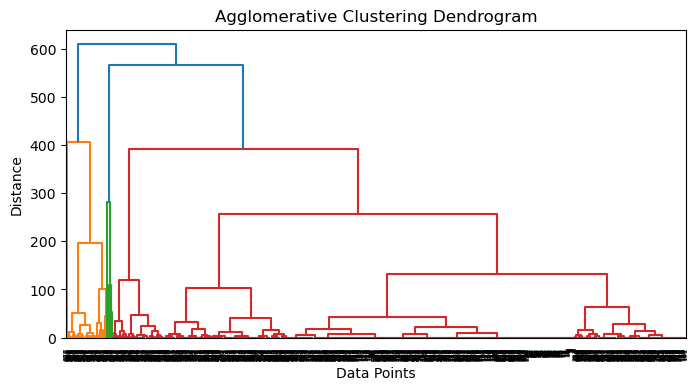

In [ ]:
clusterdata = np.array(init_data["current_vs_pre2020_routes"])
clusterdata = clusterdata.reshape(-1, 1) #convert 2d array
Z = linkage(clusterdata, method='ward')
# Plots dendrogram
plt.figure(figsize=(8, 4))
dendrogram(Z)
plt.title('Agglomerative Clustering Dendrogram')
plt.xlabel('Data Points')
plt.ylabel('Distance')
plt.show()

In [17]:
# Cut the tree into 3 clusters
labels = fcluster(Z, t=3, criterion='maxclust')
print(len(labels))
print("Unique Cluster labels:", set(labels))

978
Unique Cluster labels: {1, 2, 3}


In [16]:
#add a new column to the cluster data and save 
init_data["clusters_2020_now"] = labels
init_data.head(n=1)

,iata_source,Route_count,pre_2022_route_count,pre_2020_route_count,current_source_airports_details.city,current_source_airports_details.country,current_source_airports_details.latitude,current_source_airports_details.longitude,current_vs_pre2020_routes,pre2022_vs_pre2020_routes,current_vs_pre2022_routes,current_source_airports_details.wiki_name,clusters_2020_now
0,FUK,110,110,110,Fukuoka,Japan,33.586,130.45,0,0,0,Fukuoka_Airport,3


In [ ]:
init_data.to_csv("./data/airport_changes_clusters.csv", encoding="utf-8")